## در این مثال داده های مصرف گاز طبیعی در بخش های مختلف از مدیریت اطلاعات انرژی آمریکا استفاده شده است
فایل دیتاست را از آدرس زیر دانلود و در پوشه کاری قرار دهید.

https://github.com/hojatollahgholami/AI-in-Oil-and-gas-industry/blob/main/ex3-9/MER_T04_03.csv

در این مثال، از نمودارهای وابستگی جزئی، GAM، SHAP و ALE برای تحلیل های بینشی در حوزه انرژی استفاده می شود.

### نصب کتابخانه های مورد نیاز

In [1]:
!pip install ipywidgets xgboost shap pyGAM PyALE pdpbox arabic_reshaper python_bidi alibi

### فراخوانی کتابخانه های مورد نیاز

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import math

# کتابخانه های بینشی
from pdpbox.pdp import PDPIsolate
from alibi.explainers import ALE
from pygam import LinearGAM, s, f
import shap

### تعریف پارامترها و توابع کمکی

In [3]:
# ایجاد mapping برای بخش‌ها بر اساس Column_Order
sector_mapping = {
    1: 'Natural Gas Consumed by the Residential Sector',
    2: 'Natural Gas Consumed by the Commercial Sector',
    3: 'Natural Gas Consumed by the Industrial Sector, Lease and Plant Fuel',
    4: 'Natural Gas Consumed by the Other Industrial Sector, CHP',
    5: 'Natural Gas Consumed by the Other Industrial Sector, Non-CHP',
    6: 'Natural Gas Consumed by the Other Industrial Sector, Total',
    7: 'Natural Gas Consumed by the Industrial Sector, Total',
    8: 'Natural Gas Consumed by the Transportation Sector, Pipelines and Distribution',
    9: 'Natural Gas Consumed by the Transportation Sector, Vehicle Fuel',
    10: 'Natural Gas Consumed by the Transportation Sector, Total',
    11: 'Natural Gas Consumed by the Electric Power Sector',
    12: 'Natural Gas Consumption, Total'
}
# انتخاب بخش مورد نظر (مثال: Electric Power)
target_sector = 'Natural Gas Consumed by the Residential Sector'

# تنظیمات فارسی‌نویسی
plt.rcParams["font.family"] = 'Adobe Arabic' 
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.size'] = 16

### بارگزاری داده ها

In [4]:
# ------------ 1. بارگذاری و مرتب‌سازی داده ------------
df = pd.read_csv("MER_T04_03.csv")  
print(df)
print(df["Column_Order"].unique())
print(df["Description"].unique())

df['sector'] = df['Column_Order'].map(sector_mapping)

          MSN  YYYYMM     Value  Column_Order  \
0     NGRCPUS  194913   992.544             1   
1     NGRCPUS  195013  1198.369             1   
2     NGRCPUS  195113  1474.725             1   
3     NGRCPUS  195213  1621.966             1   
4     NGRCPUS  195313  1685.503             1   
...       ...     ...       ...           ...   
7978  NGTCPUS  202501  3931.119            12   
7979  NGTCPUS  202502  3245.696            12   
7980  NGTCPUS  202503  2757.581            12   
7981  NGTCPUS  202504  2391.545            12   
7982  NGTCPUS  202505  2313.079            12   

                                         Description                Unit  
0     Natural Gas Consumed by the Residential Sector  Billion Cubic Feet  
1     Natural Gas Consumed by the Residential Sector  Billion Cubic Feet  
2     Natural Gas Consumed by the Residential Sector  Billion Cubic Feet  
3     Natural Gas Consumed by the Residential Sector  Billion Cubic Feet  
4     Natural Gas Consumed by the Re

### پیش پردازش

In [5]:
# تبدیل به تاریخ و مرتب‌سازی
# تبدیل YYYYMM به رشته و سپس استخراج سال و ماه
df['YYYYMM_str'] = df['YYYYMM'].astype(str)
df['year'] = df['YYYYMM_str'].str[:4].astype(int)
df['month'] = df['YYYYMM_str'].str[4:].astype(int)
# فیلتر کردن مقادیر معتبر ماه (1 تا 12)
df = df[df['month'].between(1, 12)]

# ایجاد تاریخ بر اساس سال و ماه
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

# مرتب‌سازی بر اساس تاریخ
df = df.sort_values('date').reset_index(drop=True)

df_sector = df[df['sector'] == target_sector].copy()

# ایجاد ویژگی‌های زمانی
df_sector['value_lag1'] = df_sector['Value'].shift(1).astype(float)  # مقدار ماه قبل
df_sector['rolling_3_mean'] = df_sector['Value'].shift(1).rolling(3, min_periods=1).mean()  # میانگین متحرک ۳ ماهه

# حذف مقادیر NaN ناشی از shift
df_sector = df_sector.dropna(subset=['value_lag1', 'rolling_3_mean'])

# تعریف ویژگی‌ها و هدف
X = df_sector[['month', 'year', 'value_lag1', 'rolling_3_mean']]
y = df_sector['Value']

# تقسیم داده به ترتیب زمانی
test_size = 0.2
split_idx = int(len(X) * (1 - test_size))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("تعداد نمونه‌های آموزشی:", len(X_train))
print("تعداد نمونه‌های آزمایشی:", len(X_test))

# استانداردسازی
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

تعداد نمونه‌های آموزشی: 502
تعداد نمونه‌های آزمایشی: 126


### آموزش مدل با XGBoost

In [6]:
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dtest  = xgb.DMatrix(X_test_scaled, label=y_test)
params = {"objective":"reg:squarederror", "max_depth":4, "eta":0.1}
bst = xgb.train(params, dtrain, num_boost_round=200, evals=[(dtest,'test')], early_stopping_rounds=10, verbose_eval=False)

### نمایش نمودار PDP (نمودار وابستگی جزئی)

obtain pred_func from the provided model.


  0%|          | 0/10 [00:00<?, ?it/s]

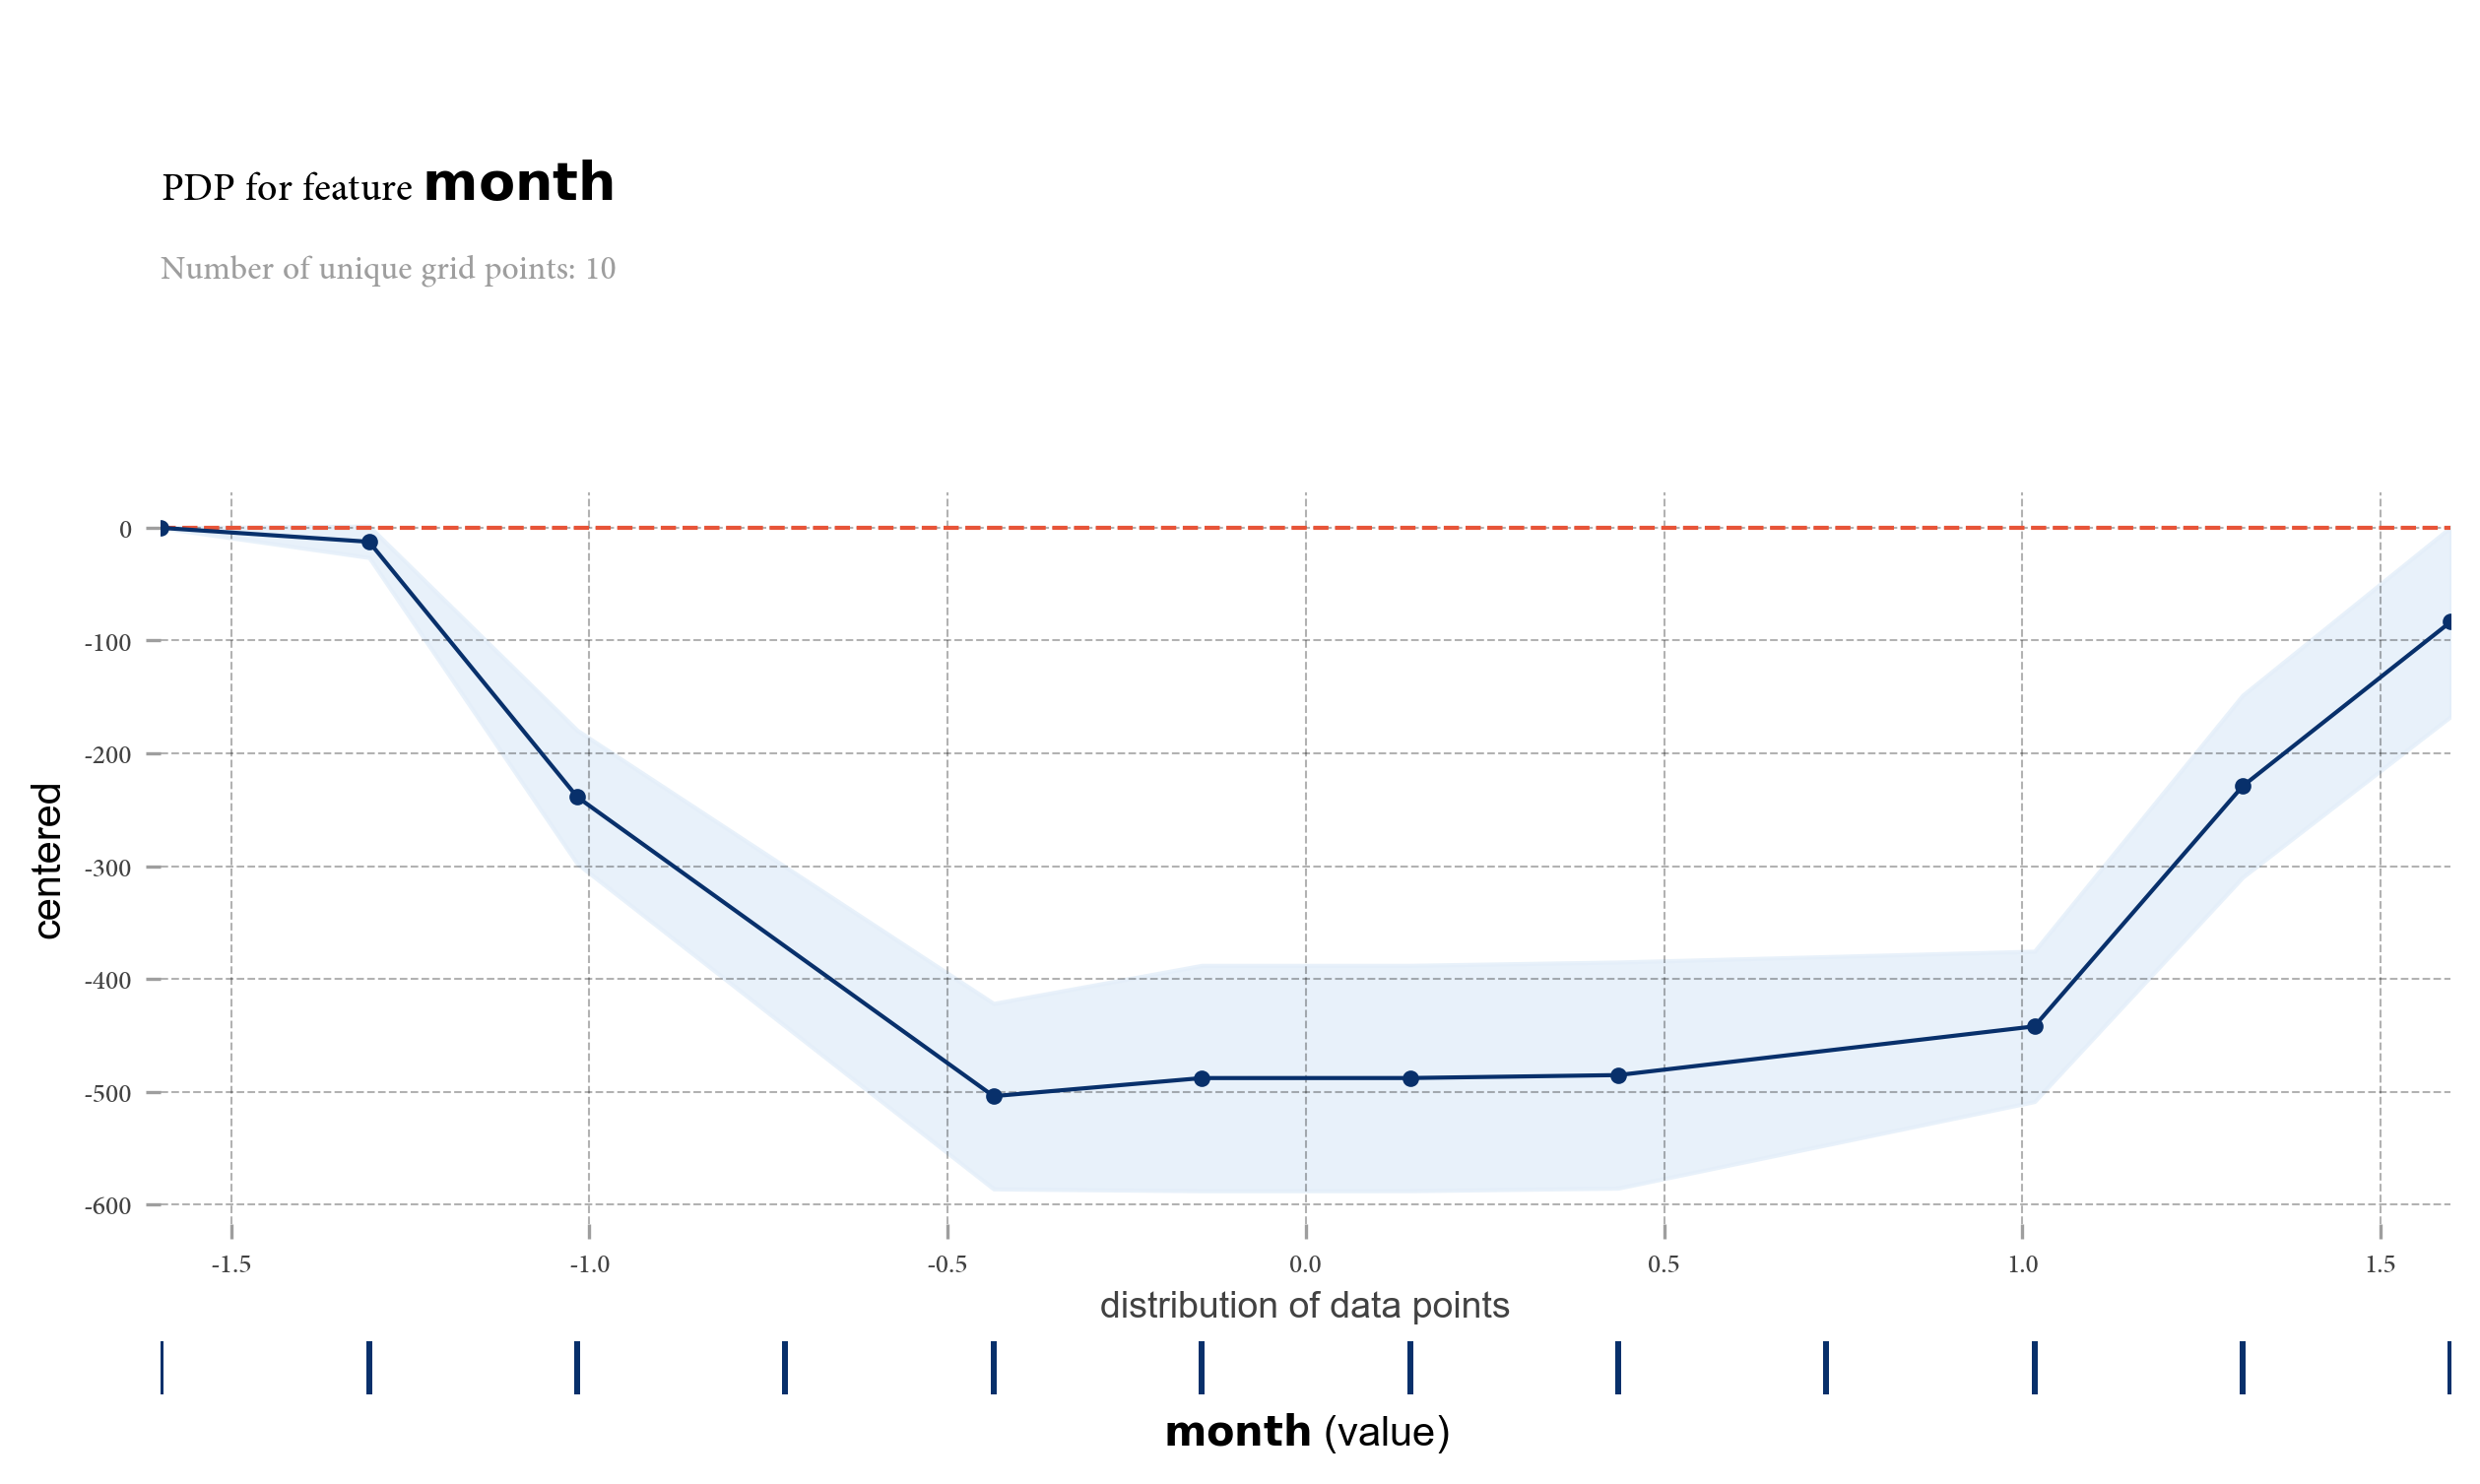

In [7]:
model_sklearn = xgb.XGBRegressor().fit(X_train_scaled, y_train)  # ساده برای pdpbox

# ایجاد PDP برای ویژگی 'month'
pdp_month = PDPIsolate(
    model=model_sklearn, 
    df=pd.DataFrame(X_train_scaled, columns=X_train.columns), 
    model_features=X_train.columns, 
    feature='month',
    feature_name='month',
    n_classes=0
)

# رسم نمودار
fig, axes = pdp_month.plot(
    engine='matplotlib',  # مطمئن شوید از 'matplotlib' استفاده می‌کند
    plot_pts_dist=True,   # نمایش توزیع داده‌ها
    figsize=(10, 6)       # تنظیم اندازه نمودار
)
plt.tight_layout()  # برای بهبود چیدمان
plt.savefig("PDP.png")
plt.show()

این نمودار نشان می‌ دهد چگونه تغییر در مقدار ویژگی «ماه» (به‌ صورت عددی) می‌ تواند پیش‌بینی مدل را نسبت به مقدار پایه براساس هدف انتخابی جا به‌ جا کند.
داده‌ی «ماه» حول میانگین و بر حسب انحراف معیار استاندارد شده.
#### روند کلی منحنی
• 	منحنی اصلی خطی‌مانند است و هرگاه مقدار آن بالای خط قرمز (صفر) قرار گیرد، مدل پیش‌بینی‌اش را بالاتر از میانگین کلی می‌داند و هرگاه زیر صفر باشد، پیش‌بینی پایین‌تر از متوسط است.

• 	نقاط قله روی منحنی نشان‌دهنده ماه‌هایی هستند که بیشترین افزایش در پیش‌بینی را دارند. اگر این قله‌ها مثلاً حول ماه‌های گرم یا پیک فروش باشند، مدل نشان می‌دهد این ماه‌ها برای هدف ما (مصرف گاز) اهمیت بیشتری دارند.

• 	بخش‌های پایین منحنی، ماه‌هایی را نشان می‌دهند که مدل آن‌ها را کمتر مؤثر می‌داند. این ماه‌ها ممکن است فصل کم‌تقاضا یا زمان‌های تعطیلی باشند.

• 	پهنای نوار کناری منحنی نشانگر میزان نوسان یا عدم قطعیت مدل در پیش‌بینی برای هر ماه است. اگر این نوار در برخی ماه‌ها بسیار گسترده باشد، یعنی مدل روی آن نقاط داده کمی داشته یا داده‌های پراکنده‌تر بوده‌اند.

• 	ستون‌های پایین نمودار می‌گویند چه تعداد نمونه آموزشی در هر ماه وجود دارد. ماه‌هایی با ستون‌های کوتاه احتمالاً کمتر در مدل تأثیرگذار بودند و انطباق منحنی در آن‌ها قابل‌اعتماد نیست.


### نمایش نمودار ALE (Accumulated Local Effects)

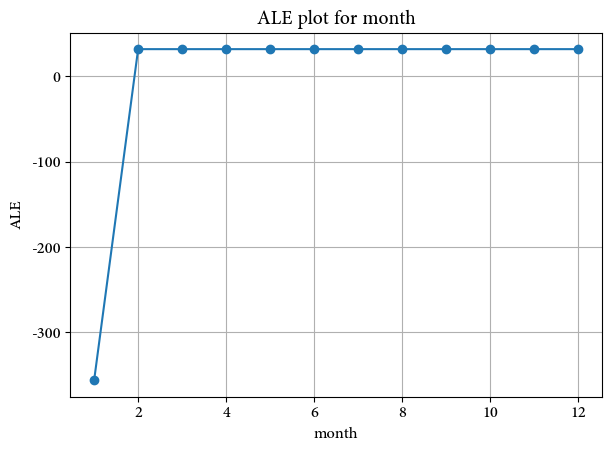

In [8]:
# تعریف ALE
ale = ALE(
    predictor=model_sklearn.predict,
    feature_names=list(X_train.columns)
)

# محاسبه ALE
exp = ale.explain(X_train.values)

# رسم نمودار
feature = 'month'

# پیدا کردن ایندکس ویژگی
idx = list(exp.feature_names).index(feature)   # به list تبدیل شد

x = exp.data['feature_values'][idx]
y = exp.data['ale_values'][idx]

plt.plot(x, y, marker='o')
plt.xlabel(feature)
plt.ylabel("ALE")
plt.title(f"ALE plot for {feature}")
plt.grid(True)
plt.tight_layout()
plt.savefig("ALE.png")
plt.show()


نمودار ALE در واقع ابزاری برای تفسیر مدل‌های یادگیری ماشین است و به ما کمک می‌ کند بفهمیم که یک ویژگی چه تأثیری محلی و تجمعی روی پیش‌ بینی مدل دارد.

### جهت اثر ویژگی

اگر نمودار روند صعودی داشته باشد (y ↑ با افزایش x)، یعنی با افزایش مقدار ویژگی، پیش‌ بینی مدل هم به‌ طور متوسط بیشتر می‌ شود.

اگر نمودار نزولی باشد، یعنی افزایش ویژگی باعث کاهش مقدار پیش‌ بینی‌ شده می‌ شود.

### شدت اثر

شیب‌ های تند یعنی ویژگی اثر قوی‌ تری روی خروجی دارد.

خطوط صاف یا نزدیک به صفر یعنس ویژگی اثر چندانی ندارد.

### اثر غیرخطی

اگر نمودار خمیده یا نوسانی باشد یعنی اثر ویژگی روی خروجی غیرخطی است (یعنی فقط افزایش یا کاهش ساده نیست).

به عنوان مثال ممکن است برای مقادیر کم ویژگی اثر مثبت، ولی برای مقادیر زیاد اثر منفی داشته باشد.

### مقایسه محدوده‌ ها

در ALE، محور افقی به بازه‌ های مختلف تقسیم می‌ شود. بنابراین می‌ توان دید در کدام بخش از مقادیر ویژگی، تغییرات بیشتری در خروجی مدل ایجاد می‌ شود.

### رسم نمودار GAM (Generalized Additive Model)

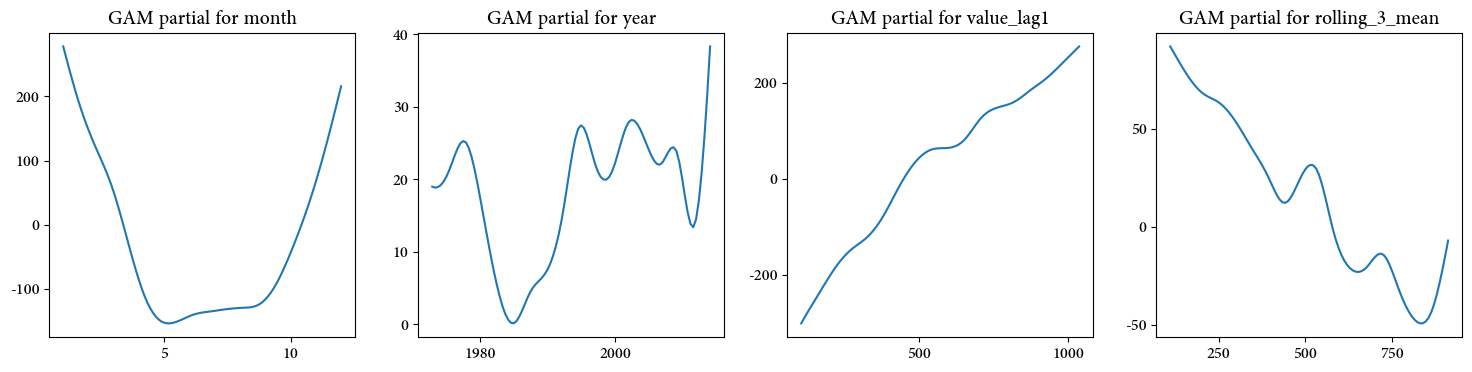

In [9]:
gam = LinearGAM(s(0) + s(1) + s(2) + s(3)).fit(X_train.values, y_train)  # s(i) برای هر فیچر
# نمایش اثر هر تابع جزء
fig, axs = plt.subplots(1, X_train.shape[1], figsize=(15,4))
for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.set_title(f'GAM partial for {X_train.columns[i]}')
plt.tight_layout()
plt.savefig("GAM.png")
plt.show()


نمودار GAN برای هر تابع جزء، یکی از بهترین ابزارهاست برای اینکه بفهمیم هر ویژگی به صورت جداگانه چه تأثیری روی خروجی مدل دارد

### شکل رابطه هر ویژگی با خروجی

هر نمودار نشان دهنده رابطه بین یک ویژگی و متغیر هدف خطی، غیرخطی، U-شکل، یا پله‌ ای است.

برخلاف رگرسیون خطی، که فقط اثر خطی را در نظر می‌ گیرد، این نمودار می‌ تواند منحنی‌ های انعطاف‌ پذیر مثل (spline) بسازد.

### میزان و جهت اثر

اگر نمودار صعودی باشد یعنی با افزایش مقدار آن ویژگی، پیش‌ بینی مدل زیاد می‌ شود.

اگر نزولی باشد یعنی افزایش ویژگی باعث کاهش خروجی می‌ شود.

اگر بخش‌ هایی صعودی و بخش‌ هایی نزولی باشد یعنی اثر وابسته به محدوده مقدار ویژگی است (مثلاً مثبت در مقادیر پایین و منفی در مقادیر بالا).

### ناهمگنی اثرات

نمودار ممکن است نشان دهد که در بعضی بازه‌ ها ویژگی تقریباً بی‌ اثر است (نمودار صاف)، و در برخی بازه‌ ها اثر قوی دارد (نمودار پرشیب).

### قابلیت مقایسه بین فیچرها

با نگاه کردن به همه نمودارها، می‌ توان دید کدام ویژگی رابطه پیچیده‌ تری با خروجی دارند و کدام ساده‌ تر.

 اگر یک فیچر تقریباً خط صاف باشد یعنی اثر زیادی ندارد یا مدل آن را تقریباً نادیده گرفته است.

### توضیح‌ پذیری مدل

GAM ذاتاً توضیح‌ پذیرتر از مدل‌ های پیچیده مثل جنگل تصادفی یا XGBoost است. این نمودارها می‌ گویند مدل چه منطقی را یاد گرفته.

### رسم نمودار SHAP

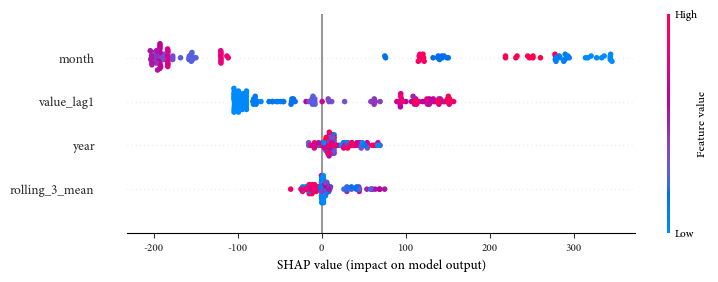

In [10]:
explainer = shap.Explainer(model_sklearn)   # or shap.TreeExplainer(bst) for raw xgboost
shap_values = explainer(X_test_scaled)
# خلاصه
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns)

نمودار خلاصه یکی از قوی‌ ترین روش‌ ها برای توضیح‌ پذیری مدل‌ های یادگیری ماشین است

این نمودار نمای کلی اهمیت ویژگی‌ ها را نشان می‌ دهد.

محور عمودی: ویژگی‌ ها (مرتب‌ شده براساس میزان اهمیت).

محور افقی: مقدار SHAP (اثر آن ویژگی روی خروجی مدل، مثبت یا منفی).

رنگ نقاط: مقدار واقعی ویژگی (مثلاً آبی = کوچک، قرمز = بزرگ).

می‌بینی آیا مقادیر بزرگ/کوچک یک ویژگی باعث افزایش یا کاهش پیش‌بینی مدل می‌شوند.

به عنوان مثال، اگر در ویژگی ماه مقادیر بالاتر (زمستان) باعث افزایش مصرف گاز باشند، نقاط قرمز سمت راست دیده می‌شوند.

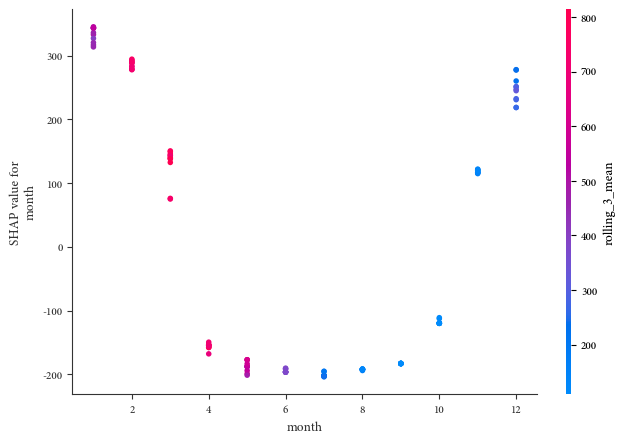

In [12]:
# dependence (یکی از ویژگی ها)
shap.dependence_plot('month', shap_values.values, X_test, feature_names=X_test.columns)

نمودار وابستگی، رابطه‌ی مقدار واقعی یک ویژگی (ماه) با مقدار SHAP آن را نشان می‌دهد.

محور افقی: مقدار واقعی ویژگی.

محور عمودی: مقدار SHAP (اثر آن روی پیش‌بینی).

هر نقطه: یک نمونه از داده تست.

رنگ نقاط: مقدار یکی دیگر از ویژگی ها که بیشترین تعامل را با این فیچر دارد (SHAP خودش انتخاب می‌کند).

این نمودار نشان می‌دهد اثر ویژگی خطی یا غیرخطی است.

اگر نقاط پراکنده باشند، یعنی اثر ویژگی وابسته به ویژگی های دیگر هم هست.

رنگ‌ ها کمک می‌ کنند تشخیص داد کدام ویژگی دیگر با این ویژگی تعامل قوی دارد.